# imports

In [1]:
from pathlib import Path
from preprocess_tools import io, signal
import numpy as np
import matplotlib.pyplot as plt

In [2]:
volume_path = Path(r"\\192.168.10.106\imdea\DataDriven_UT_AlbertoVicente\03_UT_data\Fabricacion Nacho\lente\probetas\Na_04_2\Na_04_2.tif")
saving_folder = Path(str(volume_path).replace('.tif','_amplitude.tif'))
print(f"Loading volume from {volume_path}")
io.load_tif(volume_path)
print(f"Volume will be saved as amplitude volume to {saving_folder}")

Loading volume from \\192.168.10.106\imdea\DataDriven_UT_AlbertoVicente\03_UT_data\Fabricacion Nacho\lente\probetas\Na_04_2\Na_04_2.tif
Volume will be saved as amplitude volume to \\192.168.10.106\imdea\DataDriven_UT_AlbertoVicente\03_UT_data\Fabricacion Nacho\lente\probetas\Na_04_2\Na_04_2_amplitude.tif


Aligning signal batches: 100%|██████████| 94/94 [00:00<00:00, 397.03it/s]


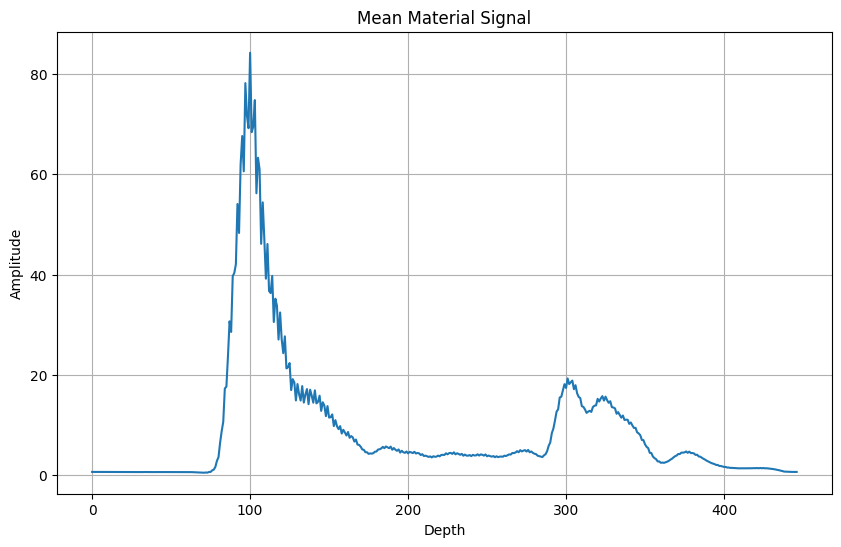

In [3]:
#load file
volume = io.load_tif(volume_path)

#align signals
volume = np.swapaxes(volume,0,2)
volume_shape = volume.shape
volume = volume.reshape((volume_shape[0]*volume_shape[1],1, -1))
align_point = 100
volume = signal.align_signals_optimized(volume,point=align_point)
volume = volume.reshape(volume_shape)
volume = np.swapaxes(volume,0,2)

#generate envelope signal
envelope_volume = signal.envelope(volume, axis=0)

#detect signals that are material and not background only
#we consider material those signals that have a max amplitude > 20, this value can be changed depending on the data
material_ids = np.where(np.max(envelope_volume, axis=0) > 20)
material_signals = envelope_volume[:, material_ids[0], material_ids[1]]

#create the mean material signal
mean_material_signal = np.mean(material_signals, axis=1)

#plot mean signal
plt.figure(figsize=(10, 6))
plt.plot(mean_material_signal)
plt.xlabel('Depth')
plt.ylabel('Amplitude')
plt.title('Mean Material Signal')
plt.grid(True)
plt.show()

<Axes: xlabel='Sample Index', ylabel='Amplitude'>

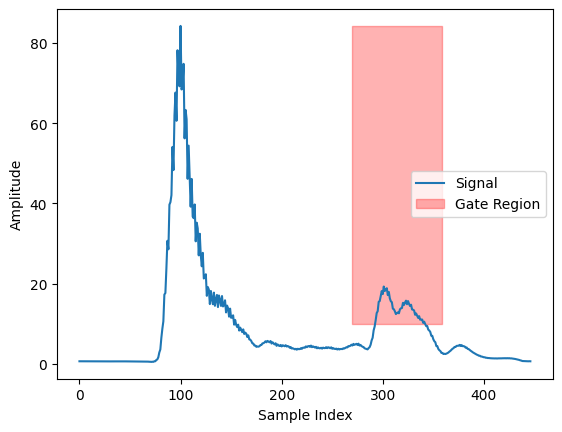

In [4]:
#Define the backwall gate
backwall_gate = (270,360,10)

#plot the second gate to check
signal.plot_gate(mean_material_signal,backwall_gate)

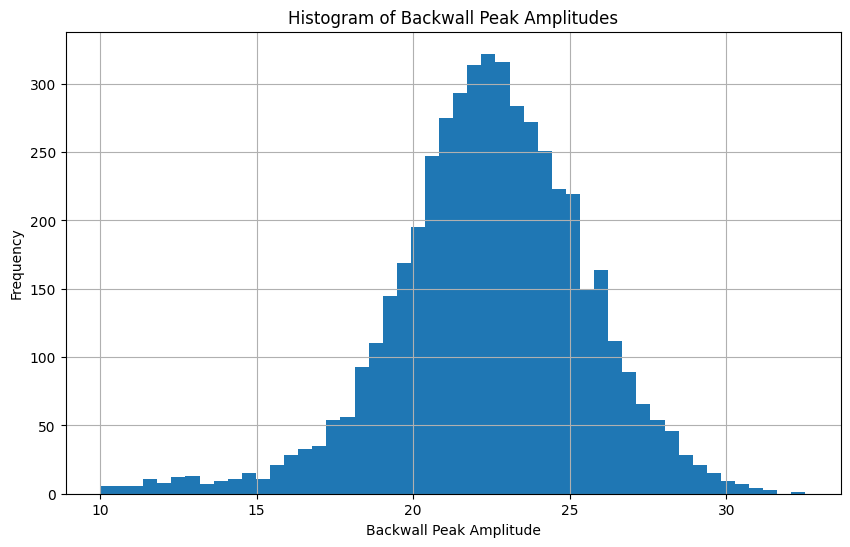

In [5]:
#for each signal get the amplitude in the backwall gate
backwall_peaks = signal.gate_max_amplitudes(material_signals, backwall_gate)

#print a histogram of the backwall peaks
plt.figure(figsize=(10, 6))
plt.hist(backwall_peaks, bins=50)
plt.xlabel('Backwall Peak Amplitude')
plt.ylabel('Frequency')
plt.title('Histogram of Backwall Peak Amplitudes')
plt.grid(True)
plt.show()